Linear regression is a statistical method used to model the relationship between a dependent variable (often denoted as $ Y $) and one or more independent variables (denoted as $ X_1, X_2, \dots, X_p $). The goal of linear regression is to find the best-fitting straight line (or hyperplane in higher dimensions) that minimizes the error between the predicted values and the actual values.

To ensure the validity and reliability of a linear regression model, several assumptions must be met. Below, I explain the **core ideas** behind each assumption:

---

### 1. **Linear Relationship**
   - **Core Idea**: The relationship between the independent variables ($ X $) and the dependent variable ($ Y $) should be approximately linear.
   - **Why It Matters**: Linear regression assumes that the effect of changes in the independent variables on the dependent variable is constant across all levels of $ X $. If this assumption is violated, the model may fail to capture the true nature of the relationship.
   - **How to Check**:
     - Scatter plots of $ Y $ vs. each $ X $ can help identify non-linear patterns.
     - Residual plots (residuals vs. predicted values) should show no systematic patterns (e.g., curves).
   - **Remedies**:
     - Transform the variables (e.g., log transformation, polynomial terms).
     - Use non-linear regression models if necessary.

---

### 2. **No Multicollinearity**
   - **Core Idea**: Independent variables should not be highly correlated with each other.
   - **Why It Matters**: Multicollinearity inflates the variance of the coefficient estimates, making them unstable and unreliable. It also makes it difficult to interpret the individual effect of each predictor.
   - **How to Check**:
     - Compute the Variance Inflation Factor (VIF): A VIF > 10 indicates problematic multicollinearity.
     - Correlation matrix: High pairwise correlations between predictors (e.g., > 0.8) suggest multicollinearity.
   - **Remedies**:
     - Remove one or more correlated predictors.
     - Use dimensionality reduction techniques like Principal Component Analysis (PCA).
     - Combine correlated variables into a single composite variable.

---

### 3. **Normality of Residuals**
   - **Core Idea**: The residuals (errors) should follow a normal distribution.
   - **Why It Matters**: Normality of residuals is critical for valid hypothesis testing (e.g., t-tests, F-tests) and confidence intervals. If residuals are not normally distributed, the p-values and confidence intervals may be unreliable.
   - **How to Check**:
     - Histogram or Q-Q plot of residuals: Should resemble a normal distribution.
     - Shapiro-Wilk test or Kolmogorov-Smirnov test for normality.
   - **Remedies**:
     - Transform the dependent variable (e.g., log, square root).
     - Use robust regression methods that do not assume normality.

---

### 4. **Homoscedasticity**
   - **Core Idea**: The variance of residuals should be constant across all levels of the independent variables.
   - **Why It Matters**: Unequal variance (heteroscedasticity) violates the assumption of equal error variances, leading to inefficient coefficient estimates and biased standard errors.
   - **How to Check**:
     - Residual plot: Residuals vs. predicted values should show no funnel-shaped pattern.
     - Breusch-Pagan test or White test for heteroscedasticity.
   - **Remedies**:
     - Transform the dependent variable (e.g., log transformation).
     - Use weighted least squares (WLS) instead of ordinary least squares (OLS).
     - Robust standard errors to account for heteroscedasticity.

---

### 5. **No Autocorrelation**
   - **Core Idea**: Residuals should not exhibit correlation with each other (especially in time series data).
   - **Why It Matters**: Autocorrelation indicates that the model has failed to capture some temporal structure in the data, leading to inefficient estimates and incorrect inference.
   - **How to Check**:
     - Durbin-Watson test: Values close to 2 indicate no autocorrelation.
     - Autocorrelation function (ACF) plot of residuals.
   - **Remedies**:
     - Include lagged variables in the model.
     - Use time series-specific models (e.g., ARIMA) if working with sequential data.
     - Generalized Least Squares (GLS) to account for autocorrelation.

---

### Summary of Assumptions and Their Core Ideas

| **Assumption**           | **Core Idea**                                                                                     |
|---------------------------|---------------------------------------------------------------------------------------------------|
| Linear Relationship       | The relationship between $ X $ and $ Y $ is linear.                                               |
| No Multicollinearity      | Independent variables are not highly correlated with each other.                                  |
| Normality of Residuals    | Errors (residuals) are normally distributed.                                                      |
| Homoscedasticity          | Variance of residuals is constant across all levels of $ X $.                                     |
| No Autocorrelation        | Residuals are uncorrelated with each other (important for time series data).                      |

---

### Final Notes
- Violations of these assumptions do not always render the model useless, but they do affect its reliability and validity.
- Diagnostic tools (e.g., residual plots, statistical tests) are essential for identifying and addressing violations.
- Remedial actions depend on the specific context and goals of the analysis.

If you have further questions about any of these assumptions or their implications, feel free to ask!

**Final Answer**: The core ideas behind the assumptions of linear regression are:
1. **Linear Relationship**: The relationship between $ X $ and $ Y $ is linear.
2. **No Multicollinearity**: Independent variables are not highly correlated.
3. **Normality of Residuals**: Errors are normally distributed.
4. **Homoscedasticity**: Residual variance is constant.
5. **No Autocorrelation**: Residuals are uncorrelated.  
$$
\boxed{\text{These assumptions ensure reliable estimation and valid inference in linear regression.}}
$$

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     1134.
Date:                Mon, 28 Apr 2025   Prob (F-statistic):           5.44e-68
Time:                        18:27:38   Log-Likelihood:                -147.62
No. Observations:                 100   AIC:                             301.2
Df Residuals:                      97   BIC:                             309.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4397      0.491     -0.896      0.3

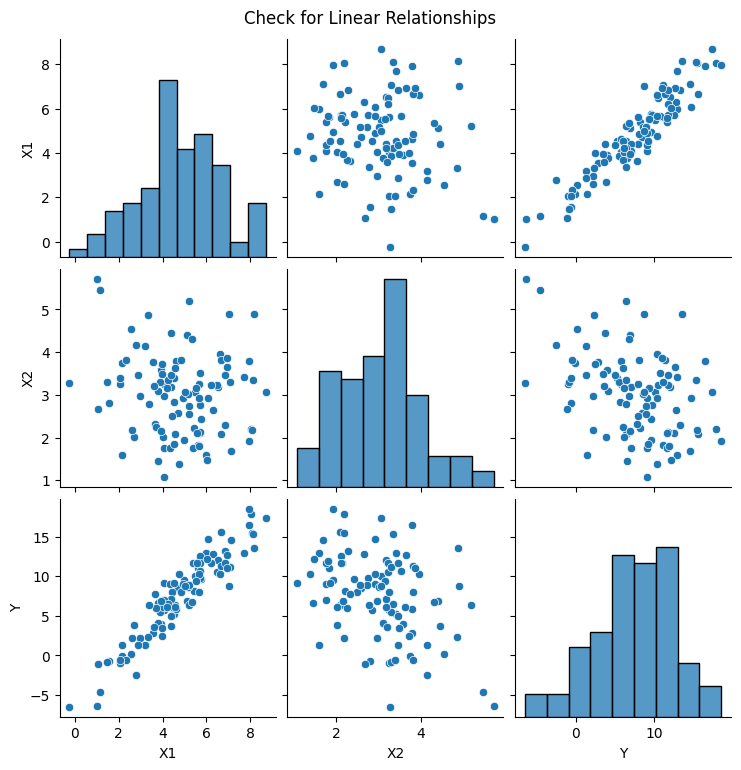


VIF Values:
   Variable        VIF
0    const  20.850468
1       X1   1.018964
2       X2   1.018964

Shapiro-Wilk Test for Normality (p-value): 0.47572645757797144


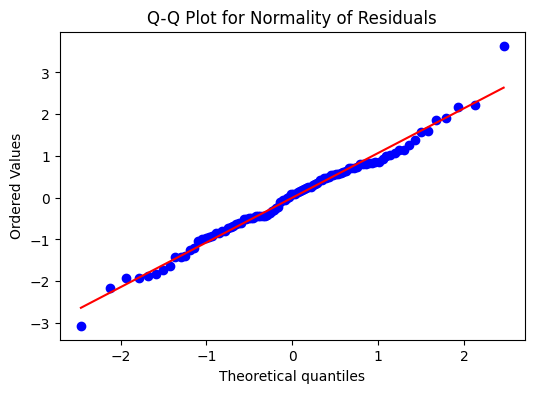


Breusch-Pagan Test for Homoscedasticity (p-value): 0.5851630505740145


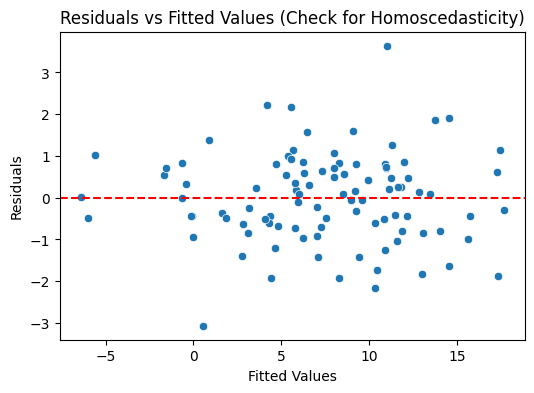


Breusch-Godfrey Test for Autocorrelation (p-value): 0.26033140170065894


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from scipy.stats import shapiro, probplot

# Sample Data (Replace with your dataset)
np.random.seed(42)
X1 = np.random.normal(5, 2, 100)
X2 = np.random.normal(3, 1, 100)
Y = 2.5 * X1 - 1.5 * X2 + np.random.normal(0, 1, 100)

# Create DataFrame
data = pd.DataFrame({'X1': X1, 'X2': X2, 'Y': Y})

# Fit Linear Regression Model
import statsmodels.api as sm
X = sm.add_constant(data[['X1', 'X2']])  # Add constant term
model = sm.OLS(data['Y'], X).fit()

# Print Model Summary
print(model.summary())

# Assumption Checks

# 1. Linear Relationship (Scatterplots)
sns.pairplot(data)
plt.suptitle("Check for Linear Relationships", y=1.02)
plt.show()

# 2. No Multicollinearity (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVIF Values:\n", vif_data)

# 3. Normality of Residuals (Shapiro-Wilk Test & Q-Q Plot)
residuals = model.resid
shapiro_test = shapiro(residuals)
print("\nShapiro-Wilk Test for Normality (p-value):", shapiro_test.pvalue)

plt.figure(figsize=(6, 4))
probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot for Normality of Residuals")
plt.show()

# 4. Homoscedasticity (Breusch-Pagan Test & Residual Plot)
bp_test = het_breuschpagan(residuals, X)
print("\nBreusch-Pagan Test for Homoscedasticity (p-value):", bp_test[1])

plt.figure(figsize=(6, 4))
sns.scatterplot(x=model.fittedvalues, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted Values (Check for Homoscedasticity)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# 5. No Autocorrelation of Error (Breusch-Godfrey Test)
bg_test = acorr_breusch_godfrey(model, nlags=1)
print("\nBreusch-Godfrey Test for Autocorrelation (p-value):", bg_test[1])